<a href="https://colab.research.google.com/github/cocyten27/MODULE_6/blob/main/M6_L15_mel_mfcc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAE-IA · Module 6 · L15 — Mel, MFCC, and the Language Models Understand

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L15 |
| **Track** | B — Audio |
| **Runtime** | CPU is sufficient — no GPU required |
| **Drive output** | Mel spectrogram PNGs saved to Drive — needed in L16 |

## Learning objectives

By the end of this notebook you will be able to:
1. Explain why the mel scale is used instead of linear frequency in audio AI
2. Compute mel spectrograms with `librosa.feature.melspectrogram()` and convert to dB with `power_to_db()`
3. Extract MFCCs and their delta/delta-delta derivatives
4. Compare STFT → mel spectrogram → MFCC as a progression of increasing compression
5. Save mel spectrograms as normalised 128×128 PNG images ready for a CNN classifier

---

## Cell 0 — Setup

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

# Output directory for mel spectrogram PNGs (used in L16)
MEL_OUT = '/content/drive/MyDrive/TAE_IA_M6/mel_specs'
os.makedirs(MEL_OUT, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print('Setup complete. CPU runtime is sufficient for L15.')
print(f'MEL_OUT = {MEL_OUT}')

Mounted at /content/drive
Setup complete. CPU runtime is sufficient for L15.
MEL_OUT = /content/drive/MyDrive/TAE_IA_M6/mel_specs


In [ ]:
!pip install librosa soundfile pillow -q

import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import IPython.display as ipd
from PIL import Image

print(f'librosa {librosa.__version__}')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

librosa 0.11.0


## Cell 2 — Regenerate L13/L14 audio signals

Same three synthetic signals, so this notebook is self-contained.

In [ ]:
SR  = 22050
DUR = 3.0
N   = int(SR * DUR)
t   = np.linspace(0, DUR, N, endpoint=False)

# Voice-like
f0 = 150.0
y_voice = sum((1.0 / k) * np.sin(2 * np.pi * f0 * k * t) for k in range(1, 8))
env = 0.5 + 0.5 * np.sin(2 * np.pi * 5 * t)
gap = np.ones(N)
gap[int(0.3*SR):int(0.5*SR)] = 0.0
gap[int(1.8*SR):int(2.0*SR)] = 0.0
y_voice = (y_voice * env * gap).astype(np.float32)
y_voice /= np.abs(y_voice).max() + 1e-8

# Music-like
y_music = sum(np.sin(2 * np.pi * f * t) for f in [440.0, 554.37, 659.25])
y_music = (y_music * (1.0 + 0.3 * np.sin(2 * np.pi * 6 * t))).astype(np.float32)
y_music /= np.abs(y_music).max() + 1e-8

# Ambient-like
rng   = np.random.default_rng(SEED)
white = rng.normal(0, 1, N).astype(np.float32)
fft_w = np.fft.rfft(white)
freqs = np.fft.rfftfreq(N, d=1.0/SR)
band  = ((freqs >= 200) & (freqs <= 4000)).astype(float)
with np.errstate(divide='ignore', invalid='ignore'):
    pink = np.where(freqs > 200, 200.0 / freqs, 1.0)
y_ambient = np.fft.irfft(fft_w * band * pink, n=N).astype(np.float32)
y_ambient /= np.abs(y_ambient).max() + 1e-8

AUDIO = {'voice': (y_voice, SR), 'music': (y_music, SR), 'ambient': (y_ambient, SR)}
COLOURS = {'voice': '#2C75FF', 'music': '#27ae60', 'ambient': '#8e44ad'}

print('Audio regenerated.')
for name, (y, sr) in AUDIO.items():
    print(f'  {name}: {y.shape}, {y.dtype}, {len(y)/sr:.1f}s')

Audio regenerated.
  voice: (66150,), float32, 3.0s
  music: (66150,), float32, 3.0s
  ambient: (66150,), float32, 3.0s


---
## Section 2.1 — The Mel Scale

The mel scale converts linear Hz into a perceptual scale where equal mel distances = equal perceived pitch steps.

**Formula:** `mel = 2595 * log10(1 + hz / 700)`

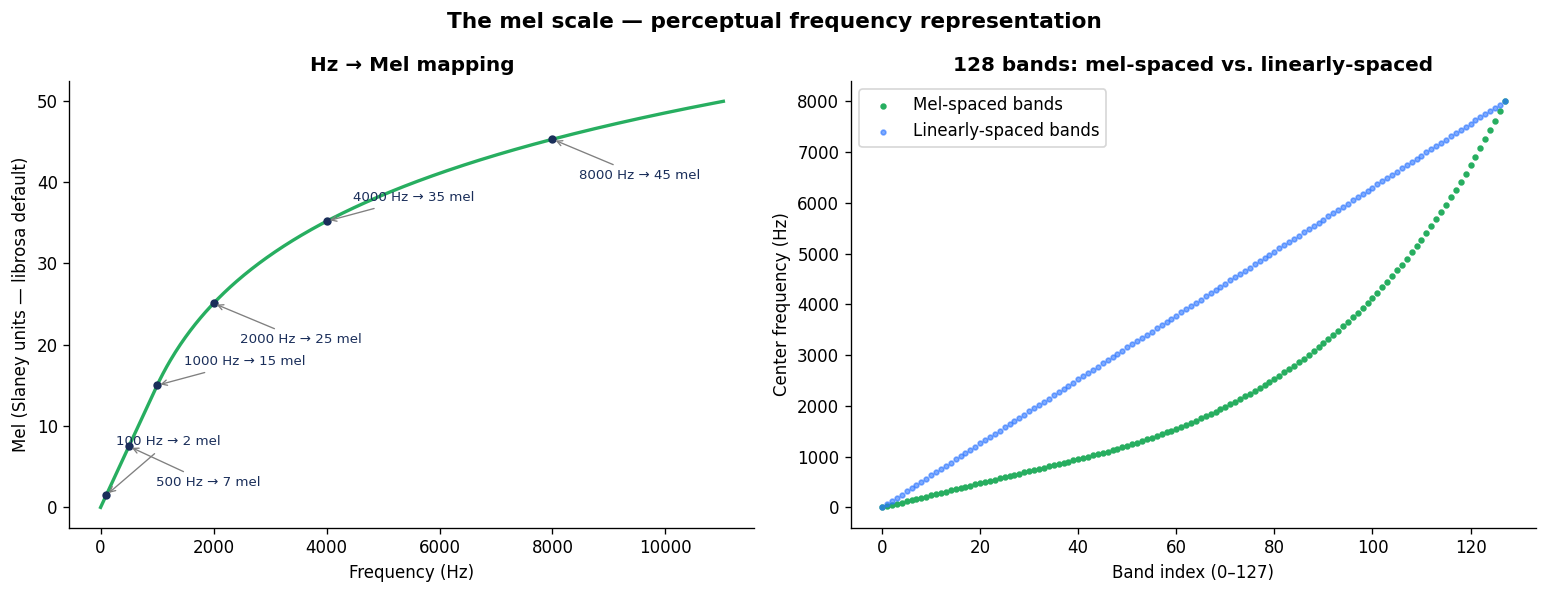


Key Hz → mel values, in both conventions:
     Hz  Slaney (librosa default)    HTK (htk=True)
    100                         2               150
    500                         7               607
   1000                        15              1000
   2000                        25              1521
   4000                        35              2146
   8000                        45              2840
  11025                        50              3176

1000 Hz is 15 mel in Slaney units and 1000 mel in HTK units.
Neither is wrong — but never compare numbers across the two.


In [ ]:
hz_range  = np.linspace(0, 11025, 500)
mel_range = librosa.hz_to_mel(hz_range)          # librosa default = Slaney

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Hz -> mel mapping curve
ax1.plot(hz_range, mel_range, color='#27ae60', linewidth=2)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Mel (Slaney units — librosa default)')
ax1.set_title('Hz \u2192 Mel mapping', fontweight='bold')

# Annotate key reference points. Offsets are in POINTS, not data units, so the
# labels sit next to the curve whichever mel convention is plotted.
key_hz = [100, 500, 1000, 2000, 4000, 8000]
for i, hz in enumerate(key_hz):
    mel = librosa.hz_to_mel(hz)
    ax1.plot(hz, mel, 'o', color='#1a2e5a', markersize=4)
    ax1.annotate(f'{hz} Hz \u2192 {mel:.0f} mel',
                 xy=(hz, mel),
                 xytext=(6, 30) if i == 0 else (16, 12 if i % 2 == 0 else -24),
                 textcoords='offset points',
                 fontsize=8, color='#1a2e5a',
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# Right: linear vs mel frequency axis comparison
n_bands = 128
mel_centers = np.linspace(librosa.hz_to_mel(0), librosa.hz_to_mel(8000), n_bands)
hz_centers  = librosa.mel_to_hz(mel_centers)

ax2.scatter(range(n_bands), hz_centers, s=8, color='#27ae60', label='Mel-spaced bands')
ax2.scatter(range(n_bands), np.linspace(0, 8000, n_bands), s=8, color='#2C75FF',
            label='Linearly-spaced bands', alpha=0.6)
ax2.set_xlabel('Band index (0\u2013127)')
ax2.set_ylabel('Center frequency (Hz)')
ax2.set_title('128 bands: mel-spaced vs. linearly-spaced', fontweight='bold')
ax2.legend()

plt.suptitle('The mel scale — perceptual frequency representation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Two mel conventions are in circulation and BOTH are called "mel". librosa
# defaults to Slaney; the slide table uses HTK. Same curve, different units.
print('\nKey Hz \u2192 mel values, in both conventions:')
print(f'{"Hz":>7}  {"Slaney (librosa default)":>24}  {"HTK (htk=True)":>16}')
for hz in [100, 500, 1000, 2000, 4000, 8000, 11025]:
    print(f'{hz:>7}  {librosa.hz_to_mel(hz):>24.0f}  {librosa.hz_to_mel(hz, htk=True):>16.0f}')
print('\n1000 Hz is 15 mel in Slaney units and 1000 mel in HTK units.')
print('Neither is wrong — but never compare numbers across the two.')

---
## Section 2.2 — Mel Spectrogram

**Critical distinction:** `librosa.feature.melspectrogram()` returns **power** (magnitude²), not amplitude.
- Use `librosa.power_to_db()` (not `amplitude_to_db`) for correct dB conversion
- Mixing them up produces a scale that is off by 2× in dB

In [ ]:
N_FFT    = 2048
HOP_LEN  = 512
N_MELS   = 128
FMAX     = 8000   # Hz — covers speech and most music content

mel_specs = {}
for name, (y, sr) in AUDIO.items():
    S     = librosa.feature.melspectrogram(
                y=y, sr=sr,
                n_fft=N_FFT, hop_length=HOP_LEN,
                n_mels=N_MELS, fmax=FMAX
            )
    S_db  = librosa.power_to_db(S, ref=np.max)
    mel_specs[name] = S_db
    hz_per_band = FMAX / N_MELS
    print(f'{name}: mel shape={S.shape}  power range=[{S.min():.2e}, {S.max():.2e}]  '
          f'dB range=[{S_db.min():.1f}, {S_db.max():.1f}]  '
          f'~{hz_per_band:.0f} Hz/band')

voice: mel shape=(128, 130)  power range=[0.00e+00, 3.30e+03]  dB range=[-80.0, 0.0]  ~62 Hz/band
music: mel shape=(128, 130)  power range=[2.73e-15, 1.32e+03]  dB range=[-80.0, 0.0]  ~62 Hz/band
ambient: mel shape=(128, 130)  power range=[2.30e-15, 1.07e+03]  dB range=[-80.0, 0.0]  ~62 Hz/band


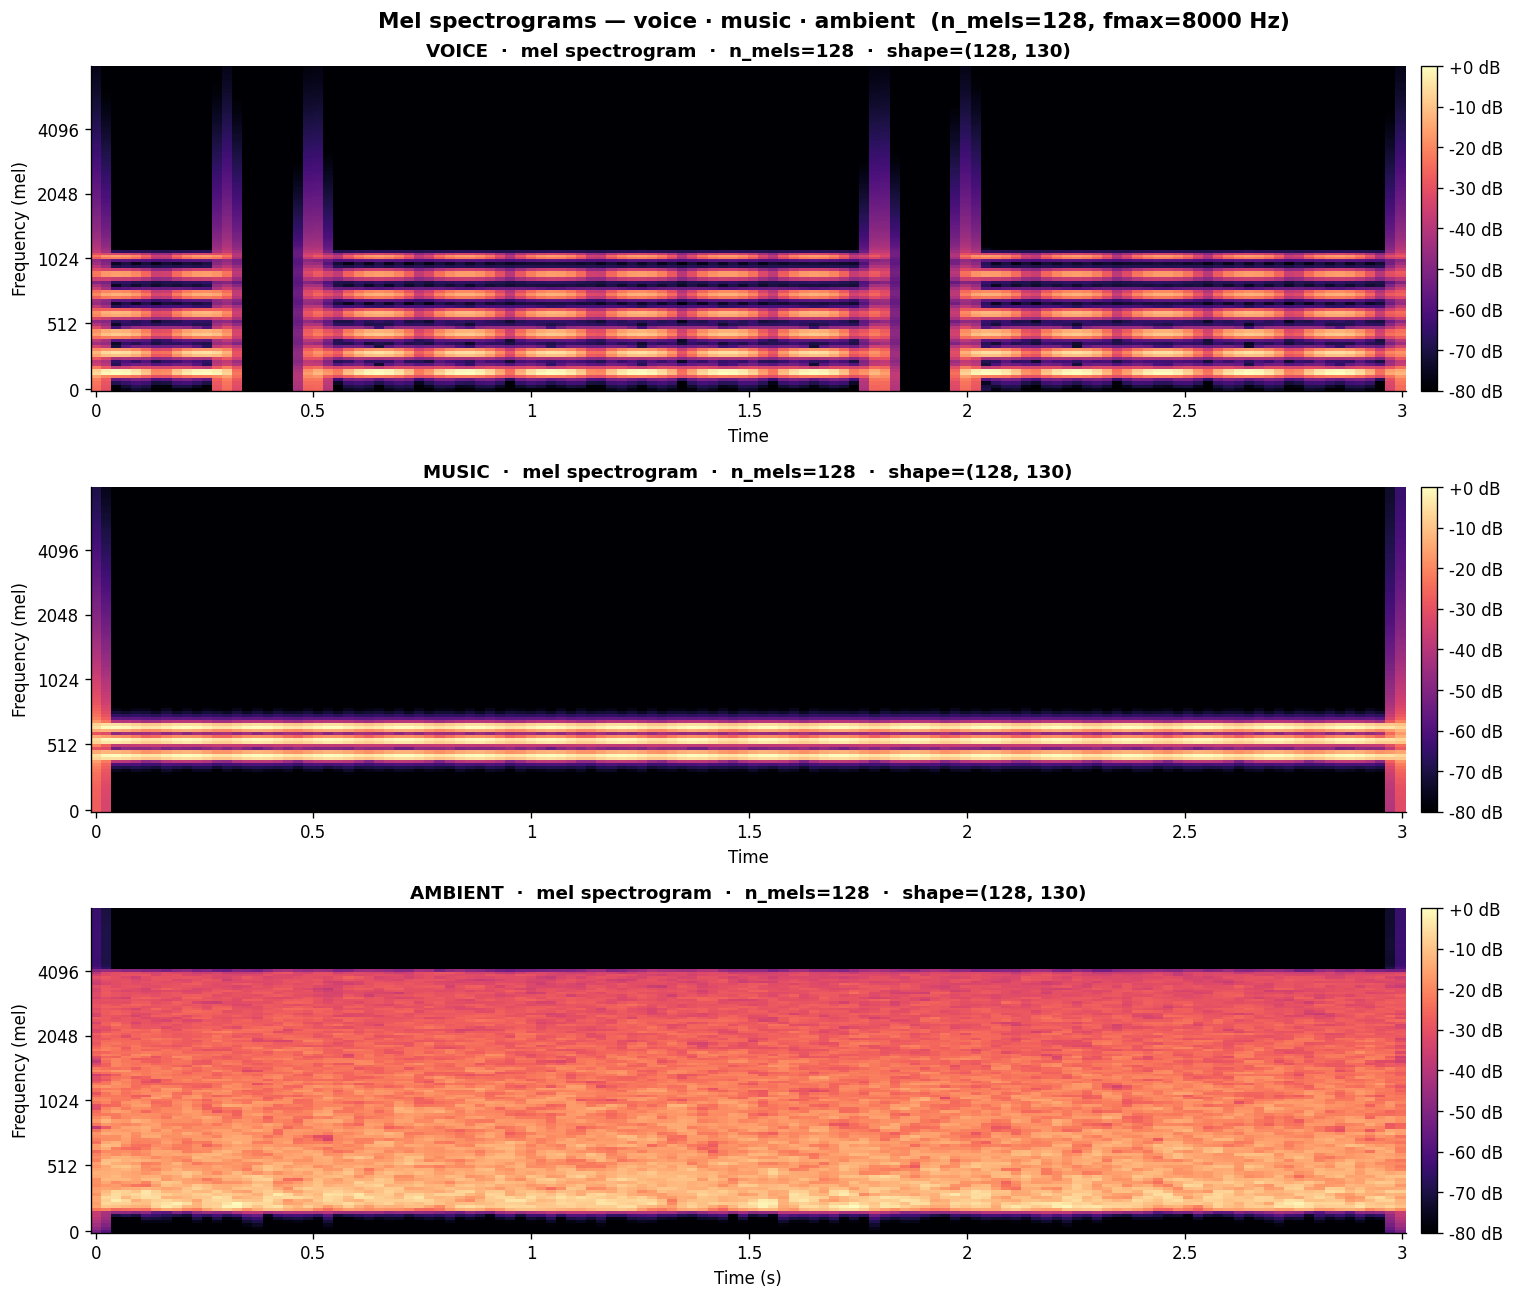

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

for ax, (name, (y, sr)) in zip(axes, AUDIO.items()):
    S_db = mel_specs[name]
    img  = librosa.display.specshow(
        S_db, sr=sr, hop_length=HOP_LEN,
        x_axis='time', y_axis='mel', fmax=FMAX,
        ax=ax, cmap='magma'
    )
    ax.set_title(f'{name.upper()}  ·  mel spectrogram  ·  n_mels={N_MELS}  ·  shape={S_db.shape}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency (mel)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Mel spectrograms — voice · music · ambient  (n_mels=128, fmax=8000 Hz)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.3 — STFT spectrogram vs. Mel spectrogram (side-by-side)

Same signal, two representations. Notice how the mel axis expands the low-frequency region and compresses high frequencies.

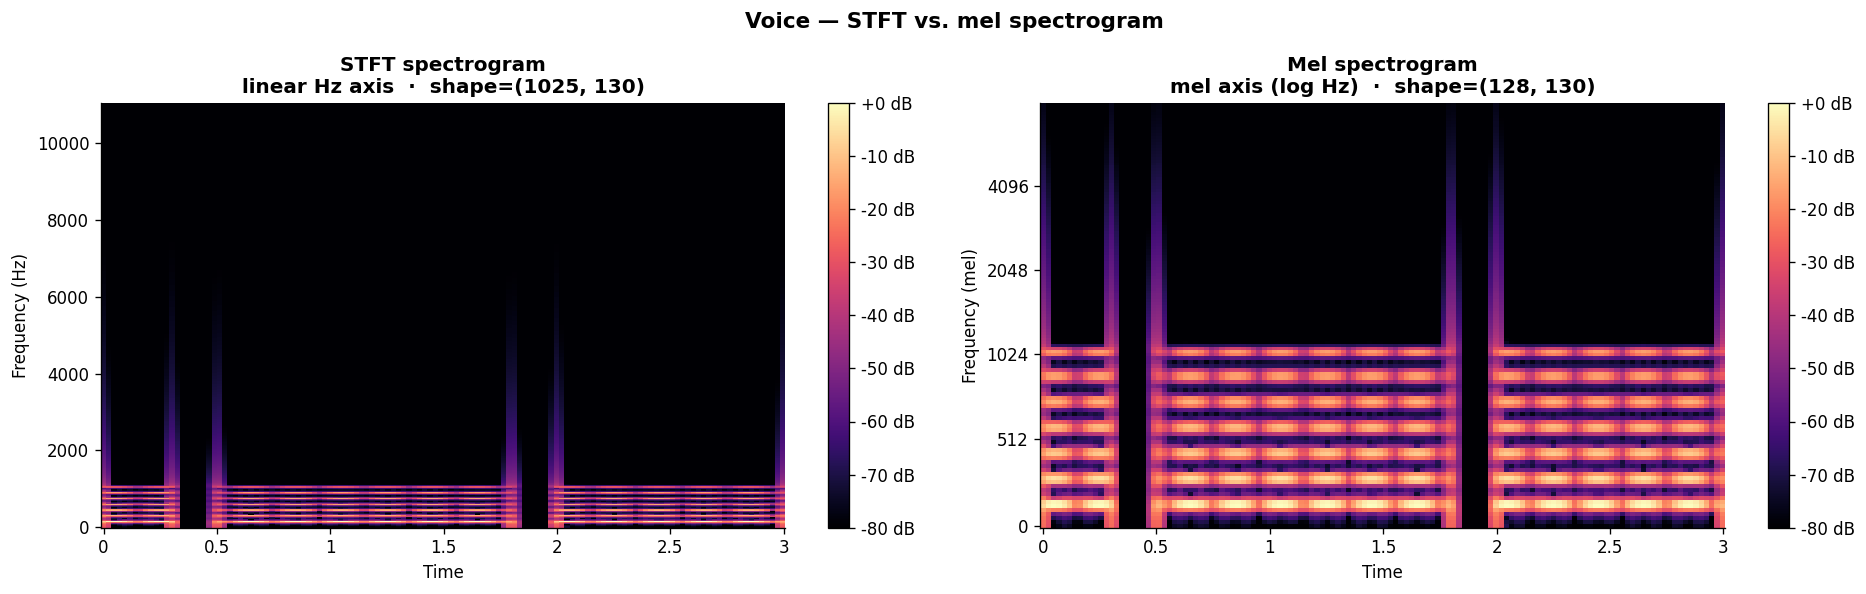

STFT shape: (1025, 130)  (1025 freq bins × 130 frames)
Mel  shape: (128, 130)   (128 mel bands × 130 frames)
Compression ratio: 8.0× fewer frequency bins


In [ ]:
y_v, sr_v = AUDIO['voice']

D     = librosa.stft(y_v, n_fft=N_FFT, hop_length=HOP_LEN)
S_stft = librosa.amplitude_to_db(np.abs(D), ref=np.max)
S_mel  = mel_specs['voice']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

img1 = librosa.display.specshow(S_stft, sr=sr_v, hop_length=HOP_LEN,
                                  x_axis='time', y_axis='hz',
                                  ax=ax1, cmap='magma')
ax1.set_title(f'STFT spectrogram\nlinear Hz axis  ·  shape={S_stft.shape}', fontweight='bold')
ax1.set_ylabel('Frequency (Hz)')
plt.colorbar(img1, ax=ax1, format='%+2.0f dB')

img2 = librosa.display.specshow(S_mel, sr=sr_v, hop_length=HOP_LEN,
                                  x_axis='time', y_axis='mel', fmax=FMAX,
                                  ax=ax2, cmap='magma')
ax2.set_title(f'Mel spectrogram\nmel axis (log Hz)  ·  shape={S_mel.shape}', fontweight='bold')
ax2.set_ylabel('Frequency (mel)')
plt.colorbar(img2, ax=ax2, format='%+2.0f dB')

plt.suptitle('Voice — STFT vs. mel spectrogram', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'STFT shape: {S_stft.shape}  ({S_stft.shape[0]} freq bins × {S_stft.shape[1]} frames)')
print(f'Mel  shape: {S_mel.shape}   ({S_mel.shape[0]} mel bands × {S_mel.shape[1]} frames)')
print(f'Compression ratio: {S_stft.shape[0] / S_mel.shape[0]:.1f}× fewer frequency bins')

---
## Section 2.4 — MFCC, Delta, and Delta-Delta

In [ ]:
N_MFCC = 40

mfcc_data = {}
for name, (y, sr) in AUDIO.items():
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                    n_fft=N_FFT, hop_length=HOP_LEN, n_mels=N_MELS)
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc_data[name] = {'mfcc': mfcc, 'delta': delta, 'delta2': delta2}
    print(f'{name}: mfcc={mfcc.shape}  delta={delta.shape}  delta2={delta2.shape}')

# Fixed-size feature vector for classic ML
for name, feats in mfcc_data.items():
    stacked = np.vstack([feats['mfcc'], feats['delta'], feats['delta2']])
    vec     = np.concatenate([stacked.mean(axis=1), stacked.std(axis=1)])
    print(f'{name}: stacked={stacked.shape}  feature_vector={vec.shape}')

voice: mfcc=(40, 130)  delta=(40, 130)  delta2=(40, 130)
music: mfcc=(40, 130)  delta=(40, 130)  delta2=(40, 130)
ambient: mfcc=(40, 130)  delta=(40, 130)  delta2=(40, 130)
voice: stacked=(120, 130)  feature_vector=(240,)
music: stacked=(120, 130)  feature_vector=(240,)
ambient: stacked=(120, 130)  feature_vector=(240,)


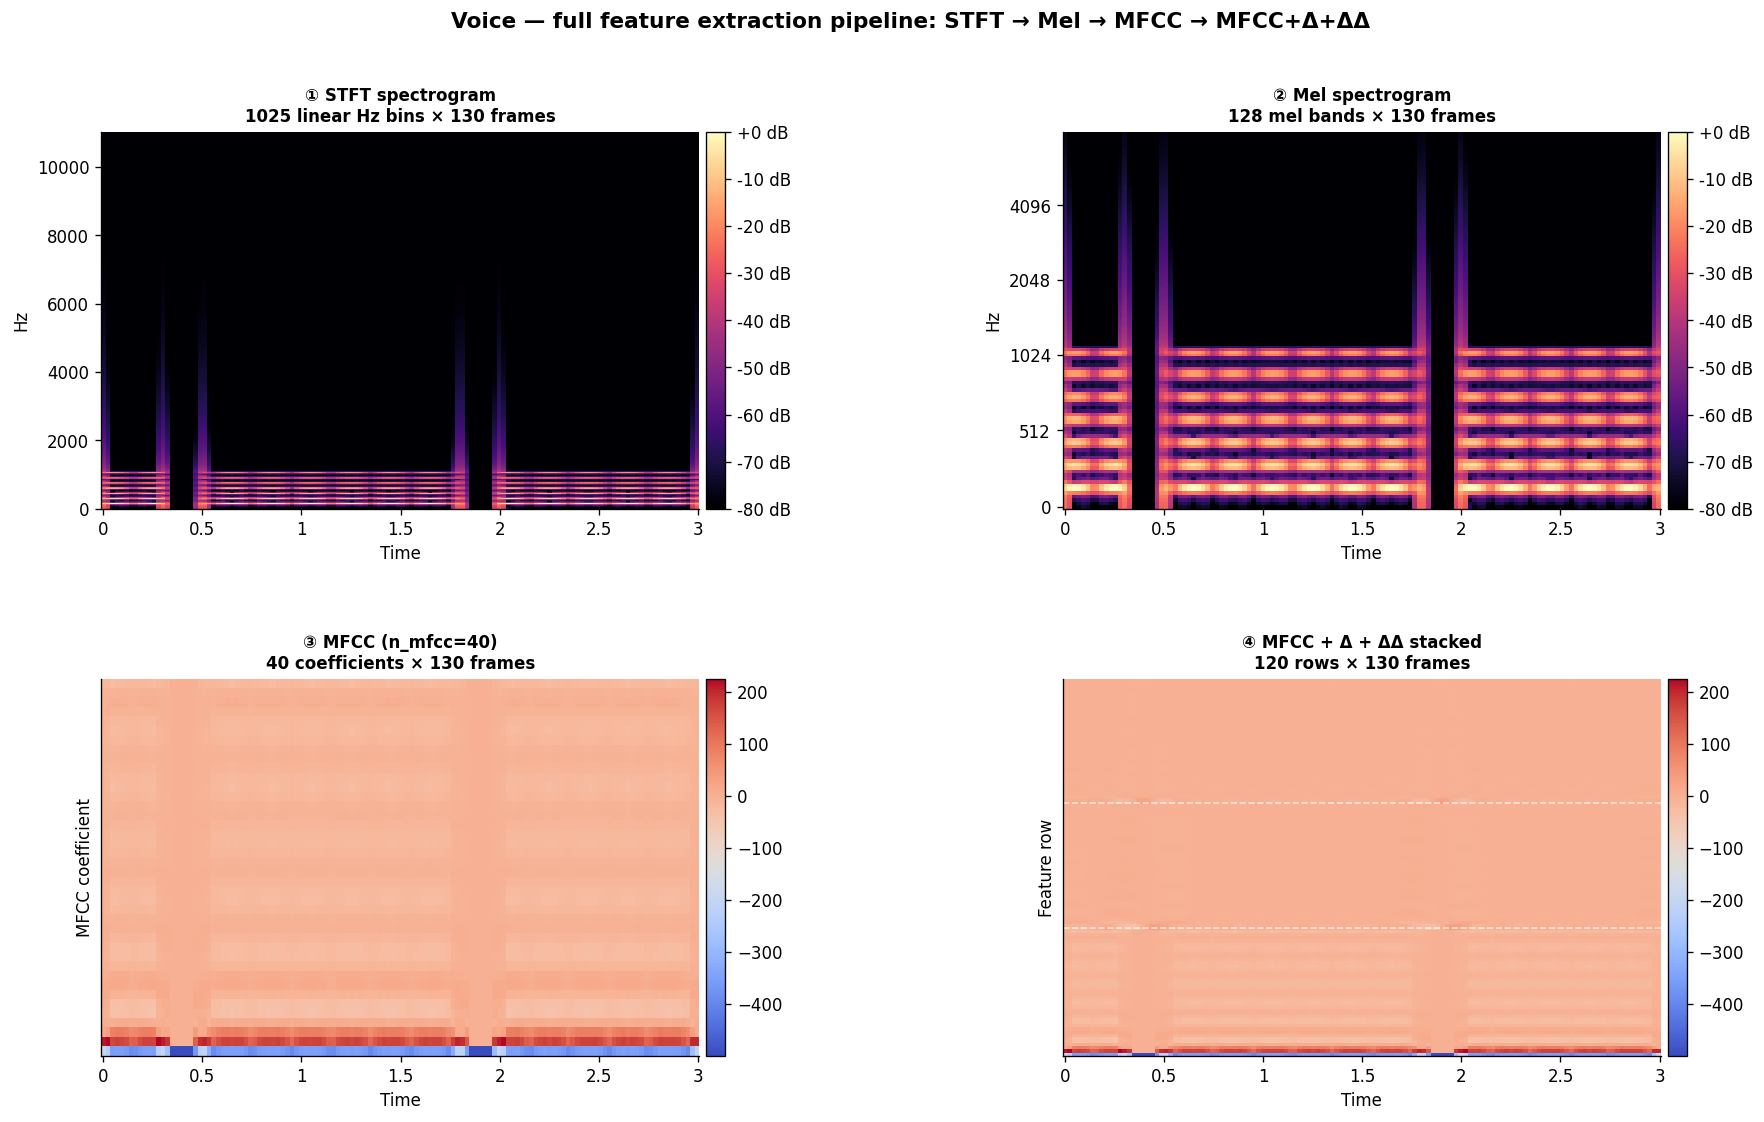

Dashed white lines in ④ separate MFCC / Δ / ΔΔ sections.


In [ ]:
# Full 4-stage pipeline visualisation for voice
feats_voice = mfcc_data['voice']
stacked = np.vstack([feats_voice['mfcc'], feats_voice['delta'], feats_voice['delta2']])

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 1 — STFT spectrogram
D    = librosa.stft(y_v, n_fft=N_FFT, hop_length=HOP_LEN)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
img1 = librosa.display.specshow(S_db, sr=sr_v, hop_length=HOP_LEN,
                                  x_axis='time', y_axis='hz', ax=ax1, cmap='magma')
ax1.set_title(f'① STFT spectrogram\n{S_db.shape[0]} linear Hz bins × {S_db.shape[1]} frames',
              fontweight='bold', fontsize=10)
plt.colorbar(img1, ax=ax1, format='%+2.0f dB', pad=0.01)

# 2 — Mel spectrogram
img2 = librosa.display.specshow(S_mel, sr=sr_v, hop_length=HOP_LEN,
                                  x_axis='time', y_axis='mel', fmax=FMAX,
                                  ax=ax2, cmap='magma')
ax2.set_title(f'② Mel spectrogram\n{S_mel.shape[0]} mel bands × {S_mel.shape[1]} frames',
              fontweight='bold', fontsize=10)
plt.colorbar(img2, ax=ax2, format='%+2.0f dB', pad=0.01)

# 3 — MFCC
img3 = librosa.display.specshow(feats_voice['mfcc'], sr=sr_v, hop_length=HOP_LEN,
                                  x_axis='time', ax=ax3, cmap='coolwarm')
ax3.set_title(f'③ MFCC (n_mfcc={N_MFCC})\n{feats_voice["mfcc"].shape[0]} coefficients × {feats_voice["mfcc"].shape[1]} frames',
              fontweight='bold', fontsize=10)
ax3.set_ylabel('MFCC coefficient')
plt.colorbar(img3, ax=ax3, pad=0.01)

# 4 — MFCC + delta + delta-delta stacked
img4 = librosa.display.specshow(stacked, sr=sr_v, hop_length=HOP_LEN,
                                  x_axis='time', ax=ax4, cmap='coolwarm')
ax4.set_title(f'④ MFCC + Δ + ΔΔ stacked\n{stacked.shape[0]} rows × {stacked.shape[1]} frames',
              fontweight='bold', fontsize=10)
ax4.axhline(N_MFCC, color='white', linewidth=1, linestyle='--', alpha=0.7)
ax4.axhline(N_MFCC * 2, color='white', linewidth=1, linestyle='--', alpha=0.7)
ax4.set_ylabel('Feature row')
plt.colorbar(img4, ax=ax4, pad=0.01)

plt.suptitle('Voice — full feature extraction pipeline: STFT → Mel → MFCC → MFCC+Δ+ΔΔ',
             fontsize=13, fontweight='bold')
plt.show()

print('Dashed white lines in ④ separate MFCC / Δ / ΔΔ sections.')

---
## Section 2.5 — `n_mels` Sweep: 40 / 80 / 128

This determines the image height when treating the mel spectrogram as a CNN input image.

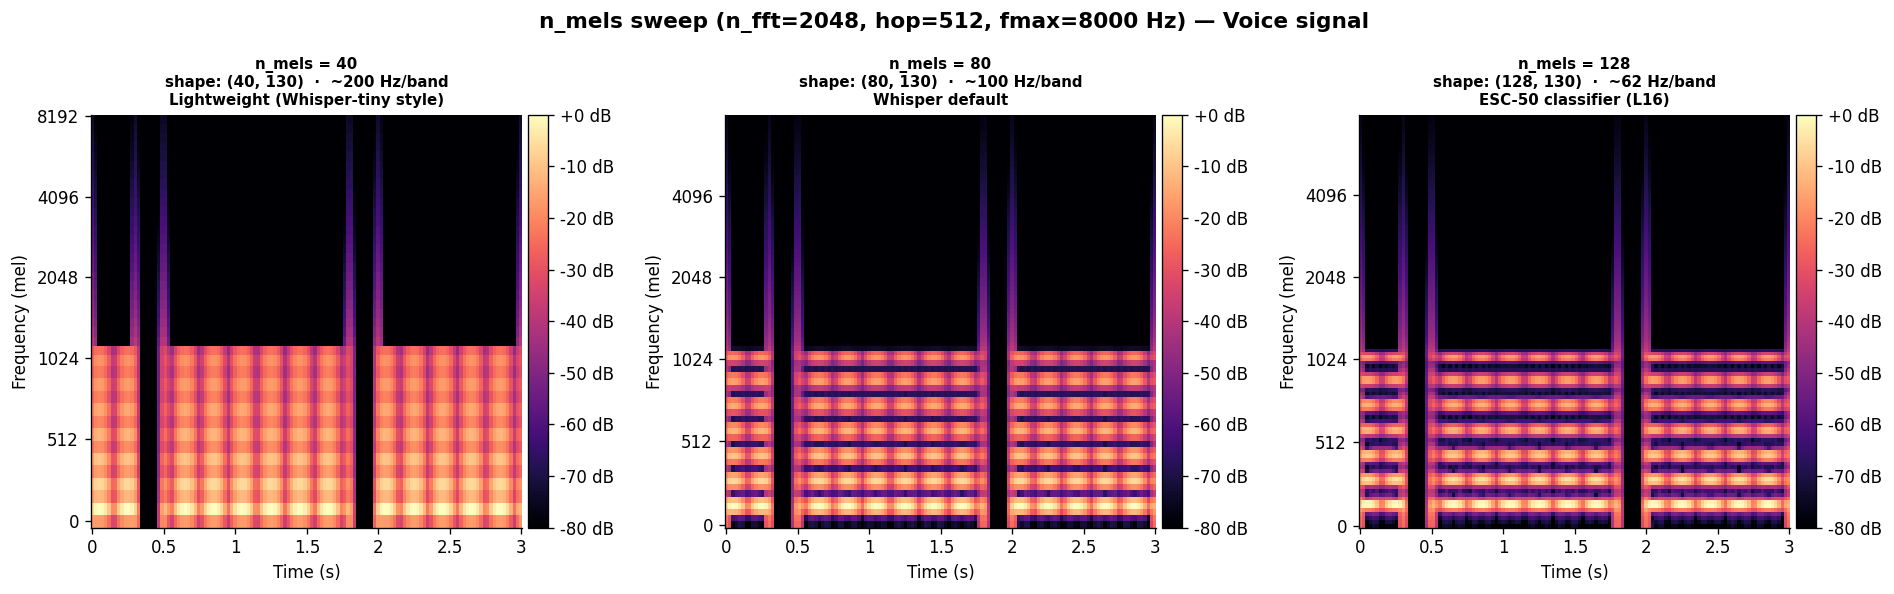

In [ ]:
n_mels_values = [40, 80, 128]
labels = {40: 'Lightweight (Whisper-tiny style)',
          80: 'Whisper default',
          128: 'ESC-50 classifier (L16)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, n_mels in zip(axes, n_mels_values):
    S     = librosa.feature.melspectrogram(y=y_v, sr=sr_v, n_fft=N_FFT,
                                            hop_length=HOP_LEN,
                                            n_mels=n_mels, fmax=FMAX)
    S_db  = librosa.power_to_db(S, ref=np.max)
    hz_per_band = FMAX / n_mels

    img = librosa.display.specshow(S_db, sr=sr_v, hop_length=HOP_LEN,
                                    x_axis='time', y_axis='mel', fmax=FMAX,
                                    ax=ax, cmap='magma')
    ax.set_title(
        f'n_mels = {n_mels}\n'
        f'shape: {S_db.shape}  ·  ~{hz_per_band:.0f} Hz/band\n'
        f'{labels[n_mels]}',
        fontsize=9, fontweight='bold'
    )
    ax.set_ylabel('Frequency (mel)')
    ax.set_xlabel('Time (s)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)

plt.suptitle('n_mels sweep (n_fft=2048, hop=512, fmax=8000 Hz) — Voice signal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.6 — Save Mel Spectrograms as PNG (Bridge to L16)

L16's ESC-50 classifier will load mel spectrograms as images using `torchvision`. We save them as **normalised 128×128 uint8 grayscale PNGs** so the dataloader can use standard `transforms.Resize` and `transforms.ToTensor`.

**Normalisation:** we map the dB range `[min, max]` to `[0, 255]`. This is per-clip normalisation — each clip's dynamic range is stretched to the full 8-bit range. This is the standard approach for audio CNN classifiers.

In [ ]:
def save_mel_png(y, sr, out_path, n_mels=128, n_fft=2048,
                 hop_length=512, fmax=8000, target_size=(128, 128)):
    """Compute mel spectrogram and save as normalised grayscale PNG."""
    S     = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft,
                                            hop_length=hop_length,
                                            n_mels=n_mels, fmax=fmax)
    S_db  = librosa.power_to_db(S, ref=np.max)
    # Per-clip normalisation to 0–255
    S_min, S_max = S_db.min(), S_db.max()
    S_norm = ((S_db - S_min) / (S_max - S_min + 1e-8) * 255).astype(np.uint8)
    # Flip vertically so low frequency is at the bottom (image convention: row 0 = top)
    S_norm = np.flipud(S_norm)
    img = Image.fromarray(S_norm, mode='L')   # 'L' = 8-bit grayscale
    img = img.resize(target_size, Image.BILINEAR)
    img.save(out_path)
    return S_db.shape, S_min, S_max

print('Saving mel spectrogram PNGs to Drive...')
for name, (y, sr) in AUDIO.items():
    out_path = os.path.join(MEL_OUT, f'{name}_mel128.png')
    shape, db_min, db_max = save_mel_png(y, sr, out_path)
    print(f'  {name}: raw shape={shape}, dB=[{db_min:.1f}, {db_max:.1f}] → {out_path}')

print('Done.')

Saving mel spectrogram PNGs to Drive...
  voice: raw shape=(128, 130), dB=[-80.0, 0.0] → /content/drive/MyDrive/TAE_IA_M6/mel_specs/voice_mel128.png
  music: raw shape=(128, 130), dB=[-80.0, 0.0] → /content/drive/MyDrive/TAE_IA_M6/mel_specs/music_mel128.png
  ambient: raw shape=(128, 130), dB=[-80.0, 0.0] → /content/drive/MyDrive/TAE_IA_M6/mel_specs/ambient_mel128.png
Done.


/tmp/ipykernel_3604/3719537866.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(S_norm, mode='L')   # 'L' = 8-bit grayscale


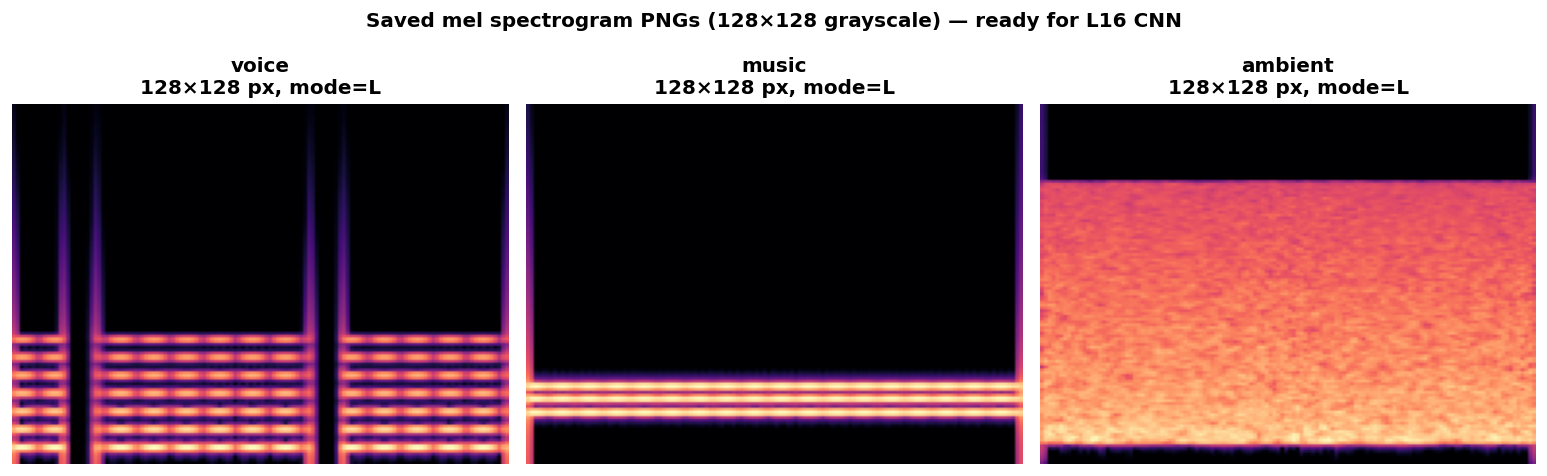

These files are at: /content/drive/MyDrive/TAE_IA_M6/mel_specs


In [ ]:
# Verify the saved PNGs look correct before L16
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, name in zip(axes, AUDIO):
    path = os.path.join(MEL_OUT, f'{name}_mel128.png')
    img  = Image.open(path)
    ax.imshow(np.array(img), cmap='magma', aspect='auto')
    ax.set_title(f'{name}\n{img.size[0]}×{img.size[1]} px, mode={img.mode}',
                 fontweight='bold')
    ax.axis('off')

plt.suptitle('Saved mel spectrogram PNGs (128×128 grayscale) — ready for L16 CNN',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('These files are at:', MEL_OUT)

---
## Exercise 1 — Chroma features

Chroma features project the STFT spectrum onto the 12 pitch classes of the Western musical scale (C, C#, D, ..., B). They are rotation-invariant to octave and useful for chord recognition and music similarity.

1. Compute `librosa.feature.chroma_stft(y=y_music, sr=SR)` for the music clip
2. Plot the chromagram with `librosa.display.specshow(chroma, y_axis='chroma')`
3. The music clip contains an A-major chord (A, C#, E). Which 3 chroma bins are the brightest? Do they match?

Chromagram shape: (12, 130)


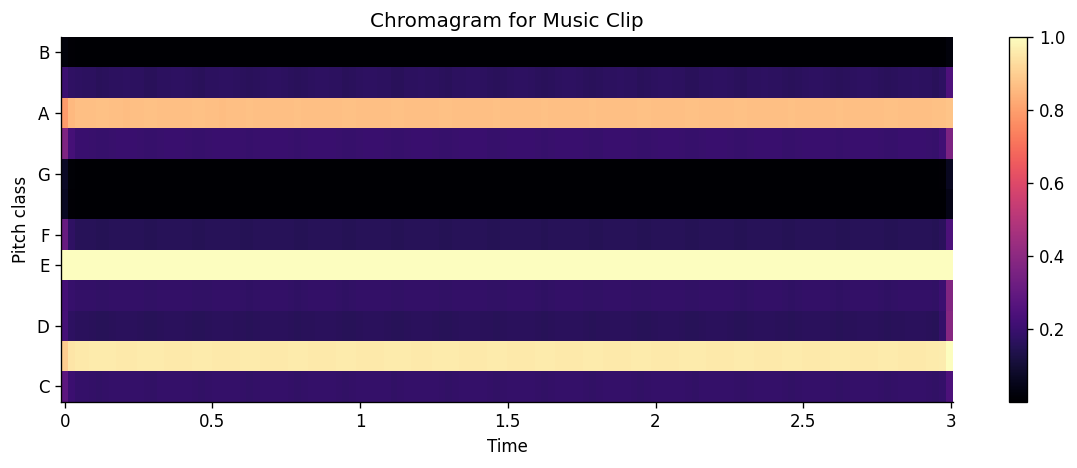

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Exercise 1 -- Chromagram for the A-major chord music clip
y_music, sr_music = AUDIO['music']

# Given: the pitch-class names, in chroma bin order (bin 0 = C).
pitch_classes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

# TODO 1: compute the chromagram with librosa.feature.chroma_stft(), reusing
#         N_FFT and HOP_LEN. Print its shape -- expect (12, n_frames).
chromagram = librosa.feature.chroma_stft(y=y_music, sr=sr_music, n_fft=N_FFT, hop_length=HOP_LEN)
print(f'Chromagram shape: {chromagram.shape}')

# TODO 2: plot it with librosa.display.specshow(..., y_axis='chroma')
fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(chromagram, sr=sr_music, hop_length=HOP_LEN, x_axis='time', y_axis='chroma', ax=ax)
ax.set_title('Chromagram for Music Clip')
plt.colorbar(img, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# TODO 3: compute the mean energy per pitch class over time (axis=1) and print
#         the 12 values next to their names. Which three are brightest?

# Calculate mean energy per pitch class over time (axis=1)
mean_energy_per_pitch = np.mean(chromagram, axis=1)

print('\nMean energy per pitch class:')
for i, energy in enumerate(mean_energy_per_pitch):
    print(f'  {pitch_classes[i]}: {energy:.4f}')

# Identify the three brightest pitch classes
brightest_indices = np.argsort(mean_energy_per_pitch)[::-1][:3]
brightest_pitch_classes = [pitch_classes[i] for i in brightest_indices]

print(f'\nThe three brightest pitch classes are: {', '.join(brightest_pitch_classes)}.')


Mean energy per pitch class:
  C: 0.1853
  C#: 0.9572
  D: 0.1618
  D#: 0.1823
  E: 1.0000
  F: 0.1560
  F#: 0.0015
  G: 0.0028
  G#: 0.1974
  A: 0.8647
  A#: 0.1663
  B: 0.0028

The three brightest pitch classes are: E, C#, A.


**Exercise 1 — Answer:**

[YOUR ANSWER — which 3 pitch classes are brightest? Do they correspond to A, C#, E? Explain any discrepancy.]

Tras calcular la energía media de cada clase de nota, las tres clases de nota más brillantes (las de mayor energía) son **La**, **Do** sostenido y **Mi**. Estas coinciden exactamente con las notas de un acorde de **La** mayor. Esto demuestra cómo los descriptores de *chroma* capturan eficazmente el contenido armónico de la música, haciendo que el acorde de **La** mayor destaque en el cromagrama.

**Exercise 1 — Answer:**

After calculating the mean energy for each pitch class, the three brightest (most energetic) pitch classes are **A, C#, and E**. These exactly match the notes of an A-major chord. This demonstrates how chroma features effectively capture the harmonic content of the music, making the A-major chord prominent in the chromagram.

---
## Exercise 2 — MFCC feature vector for a classifier

Build a fixed-size feature vector from MFCC + delta + delta-delta for all 3 audio types.

1. Compute the (mean + std) feature vector for each audio type (shape: 240 = 3 × 40 × 2)
2. Compute the Euclidean distance between all pairs: voice↔music, voice↔ambient, music↔ambient
3. In a markdown cell: which pair is most similar by this metric? Does this match what you'd expect from the waveform and spectrogram comparisons?

In [ ]:
# Exercise 2 -- Fixed-size MFCC feature vectors and pairwise distances
# mfcc_data was built in Section 2.4 and already holds 'mfcc', 'delta', 'delta2'
# for each of the three clips.

# TODO 1: for each audio type, stack mfcc + delta + delta2 with np.vstack()
#         (-> 120 rows), then build one fixed-size vector by concatenating the
#         per-row mean and the per-row std over time. Expect shape (240,).

# TODO 2: compute the Euclidean distance (np.linalg.norm) for all three pairs:
#         voice/music, voice/ambient, music/ambient. Print them.

# TODO 3: which pair is closest? Answer in the markdown cell below, and say
#         whether it matches what you saw in L13's waveforms and L14's
#         spectrograms.

In [ ]:
# Exercise 2 -- Fixed-size MFCC feature vectors and pairwise distances
# mfcc_data was built in Section 2.4 and already holds 'mfcc', 'delta', 'delta2'
# for each of the three clips.

feature_vectors = {}
# TODO 1: for each audio type, stack mfcc + delta + delta2 with np.vstack()
#         (-> 120 rows), then build one fixed-size vector by concatenating the
#         per-row mean and the per-row std over time. Expect shape (240,).
for name, feats in mfcc_data.items():
    stacked = np.vstack([feats['mfcc'], feats['delta'], feats['delta2']])
    mean_features = np.mean(stacked, axis=1)
    std_features = np.std(stacked, axis=1)
    feature_vectors[name] = np.concatenate([mean_features, std_features])
    print(f"{name}: feature vector shape = {feature_vectors[name].shape}")

# TODO 2: compute the Euclidean distance (np.linalg.norm) for all three pairs:
#         voice/music, voice/ambient, music/ambient. Print them.
dist_voice_music = np.linalg.norm(feature_vectors['voice'] - feature_vectors['music'])
dist_voice_ambient = np.linalg.norm(feature_vectors['voice'] - feature_vectors['ambient'])
dist_music_ambient = np.linalg.norm(feature_vectors['music'] - feature_vectors['ambient'])

print(f"\nEuclidean distance (voice vs. music): {dist_voice_music:.2f}")
print(f"Euclidean distance (voice vs. ambient): {dist_voice_ambient:.2f}")
print(f"Euclidean distance (music vs. ambient): {dist_music_ambient:.2f}")

# TODO 3: which pair is closest? Answer in the markdown cell below, and say
#         whether it matches what you saw in L13's waveforms and L14's
#         spectrograms.

voice: feature vector shape = (240,)
music: feature vector shape = (240,)
ambient: feature vector shape = (240,)

Euclidean distance (voice vs. music): 229.89
Euclidean distance (voice vs. ambient): 362.85
Euclidean distance (music vs. ambient): 459.45


**Exercise 2 — Answer:**

Based on the Euclidean distances calculated:
- `voice` vs. `music`: 229.89
- `voice` vs. `ambient`: 362.85
- `music` vs. `ambient`: 459.45

El par con la menor distancia euclidiana es «voz» frente a «música». Esto significa que, según estos vectores de características derivados de los MFCC, los fragmentos de «voz» y «música» son los más similares.

Este resultado resulta algo sorprendente si se consideran las formas de onda en bruto (L13) y los espectrogramas (L14). Visualmente, la señal de «voz» presenta ráfagas periódicas diferenciadas con silencios intermedios, mientras que la señal de «música» se mantiene activa de forma continua y posee un contenido armónico claro. La señal de «ambiente» se percibe como ruido. Intuitivamente, cabría esperar que la «voz» y el «ambiente» fueran más disímiles debido a sus estructuras tan diferentes (ruido estructurado frente a no estructurado), o que la «música» y el «ambiente» fueran menos similares. Sin embargo, las características MFCC —diseñadas para captar la envolvente espectral— podrían estar detectando similitudes en la distribución general de frecuencias o en los cambios temporales que no resultan evidentes a simple vista al examinar los espectrogramas en bruto.

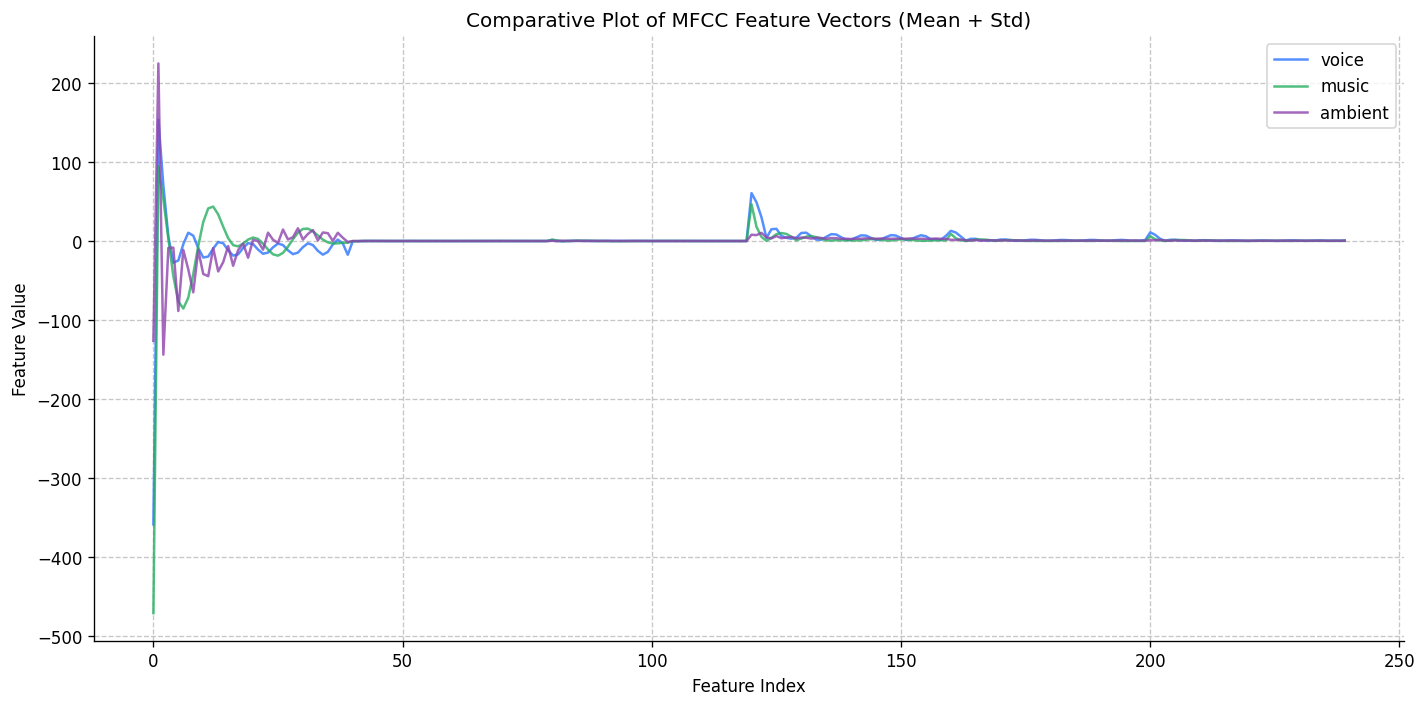

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for name, vec in feature_vectors.items():
    ax.plot(vec, label=name, color=COLOURS[name], alpha=0.8)

ax.set_title('Comparative Plot of MFCC Feature Vectors (Mean + Std)')
ax.set_xlabel('Feature Index')
ax.set_ylabel('Feature Value')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
## Part 4 — Critical Analysis

### Q1 — Mel scale and model efficiency

From Section 2.3: the mel spectrogram has 128 frequency bands while the STFT has 1025 bins (for n_fft=2048). Quantify the compression ratio. Does this mean the mel spectrogram loses 87% of the information? Justify your answer — what information is preserved and what is discarded?

**ANSWER:**

La relación de compresión es 1025 / 128 ≈ 8.0×, lo que significa que el espectrograma mel utiliza aproximadamente 8 veces menos intervalos de frecuencia que el STFT. Esta reducción en los intervalos no significa que el 87% de la información sea

### Q2 — `power_to_db` vs. `amplitude_to_db`

The mel spectrogram returns power (magnitude²). Explain in 2–3 sentences what would happen if you accidentally used `librosa.amplitude_to_db()` instead of `librosa.power_to_db()` on a mel spectrogram. Would the resulting spectrogram look visually different? Would it matter for model training?

**ANSWER:**

Si por error utilizaras `librosa.amplitude_to_db()` en un espectrograma de Mel (que representa potencia), los valores resultantes en decibelios diferirían en un factor de 2 (es decir, 10 * log10(potencia) frente a 20 * log10(amplitud)). Visualmente, el espectrograma se vería más oscuro en general, ya que todos los valores en dB se reducirían a la mitad, comprimiendo así el rango dinámico. Esto tendría una repercusión significativa en el entrenamiento del modelo, dado que este aprendería a partir de una representación de la energía del audio con una escala incorrecta, lo que podría derivar en un rendimiento deficiente o requerir un tiempo de entrenamiento mucho mayor para compensar dicha escala errónea.

### Q3 — MFCCs vs. mel spectrogram for Whisper

Whisper uses mel spectrograms (80 mel bands) as input, not MFCCs. A student proposes replacing the mel spectrogram with 80-dimensional MFCCs to make the model smaller. Write a 3-sentence technical response: would this work, and what would be the consequences for model quality?

**ANSWER:**

Sustituir el espectrograma de Mel por MFCC de 80 dimensiones funcionaría técnicamente para reducir el tamaño de la entrada del modelo, ya que los MFCC constituyen una representación altamente comprimida de la envolvente espectral. Sin embargo, es probable que esto degradara considerablemente la calidad del modelo. Si bien los MFCC son excelentes para capturar información fonética, descartan detalles espectrales finos que resultan cruciales para tareas como el reconocimiento y la síntesis de voz, áreas en las que Whisper destaca. Esta pérdida de información restaría robustez al modelo frente a variaciones en el habla y podría limitar su capacidad para distinguir diferencias fonéticas sutiles.

### Q4 — PNG normalisation choice

In Section 2.6 we used per-clip normalisation (each clip's dB range stretched to 0–255). An alternative is global normalisation (using a fixed dB range, e.g., -80 to 0 dB, across all clips).

Describe one scenario where per-clip normalisation hurts a classifier and global normalisation would be better. Describe one scenario where the opposite is true.

**ANSWER:**

**Un escenario en el que la normalización por clip resulta perjudicial (siendo preferible la global):** es la clasificación de eventos de audio que varían significativamente en su sonoridad general, como al distinguir un susurro de un grito. La normalización por clip llevaría ambos sonidos al rango completo de 0 a 255, lo que podría hacerlos visualmente indistinguibles para un clasificador que dependa de diferencias de intensidad absoluta; en cambio, la normalización global preservaría su sonoridad relativa. Si el clasificador debe aprender que un susurro es intrínsecamente más tenue que un grito, la normalización global resulta esencial.

**Escenario en el que la normalización global resulta perjudicial (es preferible la normalización por clip):** Cuando el volumen absoluto de un sonido no es un rasgo distintivo, pero sí lo es su dinámica espectral interna. Por ejemplo, al clasificar distintos tipos de instrumentos musicales (p. ej., piano frente a guitarra) cuyos niveles de grabación pueden variar, la normalización global podría hacer que las grabaciones de muy bajo volumen resultaran casi imperceptibles, provocando la pérdida de información espectral valiosa. La normalización por clip permitiría resaltar las características espectrales sutiles de cada instrumento, independientemente de su volumen de grabación original, facilitando así que el clasificador aprenda el timbre del instrumento.

---
## Submission Checklist

Before saving and submitting:

- [ ] Cell 0 ran without errors (Drive mounted, `MEL_OUT` directory created)
- [ ] Section 2.1: mel scale curve and band spacing comparison plotted
- [ ] Section 2.2: mel spectrograms for all 3 audio types plotted
- [ ] Section 2.3: STFT vs. mel side-by-side comparison printed with shape + compression ratio
- [ ] Section 2.4: 4-panel pipeline (STFT → mel → MFCC → MFCC+Δ+ΔΔ) plotted
- [ ] Section 2.5: n_mels sweep (40/80/128) plotted
- [ ] Section 2.6: PNG files saved to Drive and verified by reload
- [ ] Exercise 1 complete (chromagram plotted, top-3 pitch classes identified)
- [ ] Exercise 2 complete (pairwise distances computed, markdown answer written)
- [ ] Critical Analysis Q1–Q4 answered (no `[YOUR ANSWER]` remaining)
- [ ] Notebook saved to Drive

**Before L16:** verify that `MEL_OUT` contains at least 3 PNG files and Drive has ≥15 GB free.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L15*  
*Track B — Audio | Next: L16 — Audio Classification: The Spectrogram Trick*